# Lungelo Ndumiso Ntombela
# Data Science
# TASK 3 · Car Price Prediction 

## Objective
Predict the selling price of a used car using features such as brand, age, mileage, fuel type, transmission and present price.


### Dataset

The notebook checks for a local CarDekho CSV first and then tries a public copy.


In [1]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
RANDOM_STATE = 42


In [2]:
def load_car_dataset():
    local_candidates = [
        Path("car_data.csv"),
        Path("car data.csv"),
        Path("CarData.csv")
    ]

    for path in local_candidates:
        if path.exists():
            print(f"Loading local dataset: {path}")
            return pd.read_csv(path)

    urls = [
        "https://raw.githubusercontent.com/sumit0072/Car-Price-Prediction-Project/master/car%20data.csv"
    ]

    last_error = None
    for url in urls:
        try:
            print("Attempting to load the public CarDekho dataset...")
            return pd.read_csv(url)
        except Exception as exc:
            last_error = exc

    raise FileNotFoundError(
        "Car dataset not found. Put 'car_data.csv' or 'car data.csv' "
        "in the notebook folder and run this cell again."
    ) from last_error

car_df = load_car_dataset()
display(car_df.head())

Loading local dataset: car data.csv


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3.1 Data Inspection and Cleaning


In [3]:
print("Dataset shape:", car_df.shape)
print("\nData types:")
print(car_df.dtypes)

print("\nMissing values:")
display(car_df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows before removal:", car_df.duplicated().sum())

print("\nDescriptive statistics:")
display(car_df.describe(include="all").T)

Dataset shape: (301, 9)

Data types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Missing values:


,Missing Values
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0



Duplicate rows before removal: 2

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [4]:
# Clean column names and categorical text
car_df.columns = car_df.columns.str.strip()

categorical_columns = ["Fuel_Type", "Seller_Type", "Transmission"]

for col in categorical_columns:
    car_df[col] = car_df[col].astype("string").str.strip().str.title()

car_df["Car_Name"] = car_df["Car_Name"].astype("string").str.strip().str.lower()

for col in car_df.select_dtypes(include=np.number).columns:
    car_df[col] = car_df[col].fillna(car_df[col].median())

for col in car_df.select_dtypes(include=["object", "string", "category"]).columns:
    if car_df[col].isna().any():
        car_df[col] = car_df[col].fillna(car_df[col].mode()[0])

before = len(car_df)
car_df = car_df.drop_duplicates().reset_index(drop=True)


print(f"Duplicate rows removed: {before - len(car_df)}")
print("Dataset shape after cleaning:", car_df.shape)
print("Remaining missing values:", car_df.isnull().sum().sum())

Duplicate rows removed: 2
Dataset shape after cleaning: (299, 9)
Remaining missing values: 0


## 3.2 Feature Engineering


In [5]:
The_current_year = 2026

# Calculate age from the model year
car_df["Car_Age"] = The_current_year - car_df["Year"]
car_df["Brand"] = car_df["Car_Name"].str.split().str[0].str.title()
display(
    car_df[
        ["Car_Name", "Year", "Car_Age", "Brand",
         "Selling_Price", "Kms_Driven"]
    ].head(10)
)

,Car_Name,Year,Car_Age,Brand,Selling_Price,Kms_Driven
0,ritz,2014,12,Ritz,3.35,27000
1,sx4,2013,13,Sx4,4.75,43000
2,ciaz,2017,9,Ciaz,7.25,6900
3,wagon r,2011,15,Wagon,2.85,5200
4,swift,2014,12,Swift,4.60,42450
5,vitara brezza,2018,8,Vitara,9.25,2071
6,ciaz,2015,11,Ciaz,6.75,18796
7,s cross,2015,11,S,6.50,33429
8,ciaz,2016,10,Ciaz,8.75,20273
9,ciaz,2015,11,Ciaz,7.45,42367


## 3.3 Exploratory Data Analysis


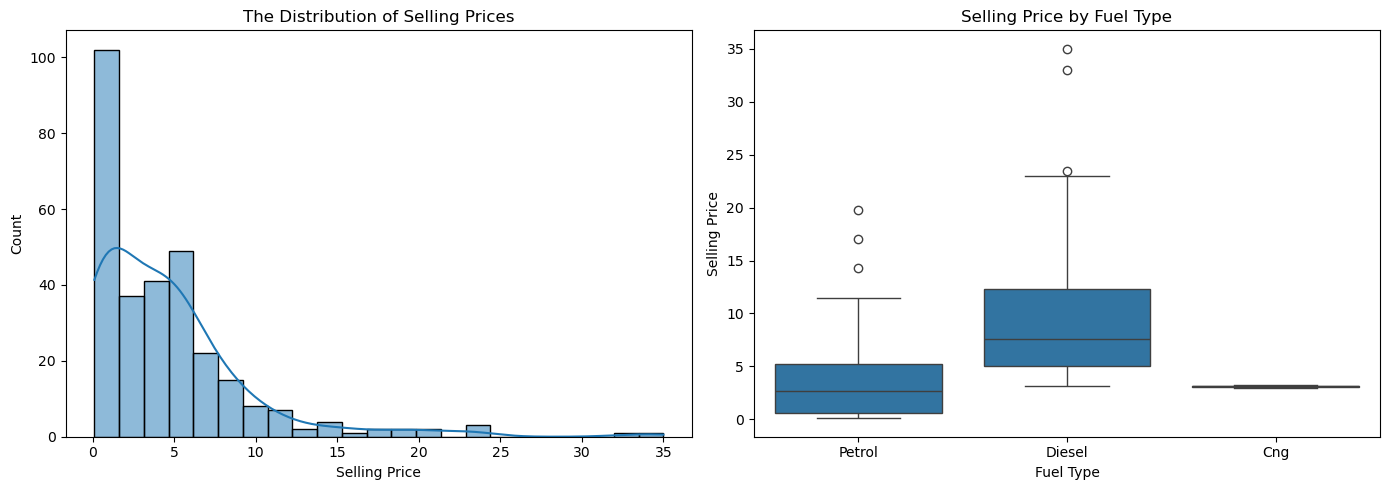

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(car_df["Selling_Price"], kde=True, ax=axes[0])
axes[0].set_title("The Distribution of Selling Prices")
axes[0].set_xlabel("Selling Price")
axes[0].set_ylabel("Count")

sns.boxplot(data=car_df, x="Fuel_Type", y="Selling_Price", ax=axes[1])
axes[1].set_title("Selling Price by Fuel Type")
axes[1].set_xlabel("Fuel Type")
axes[1].set_ylabel("Selling Price")

plt.tight_layout()
plt.show()

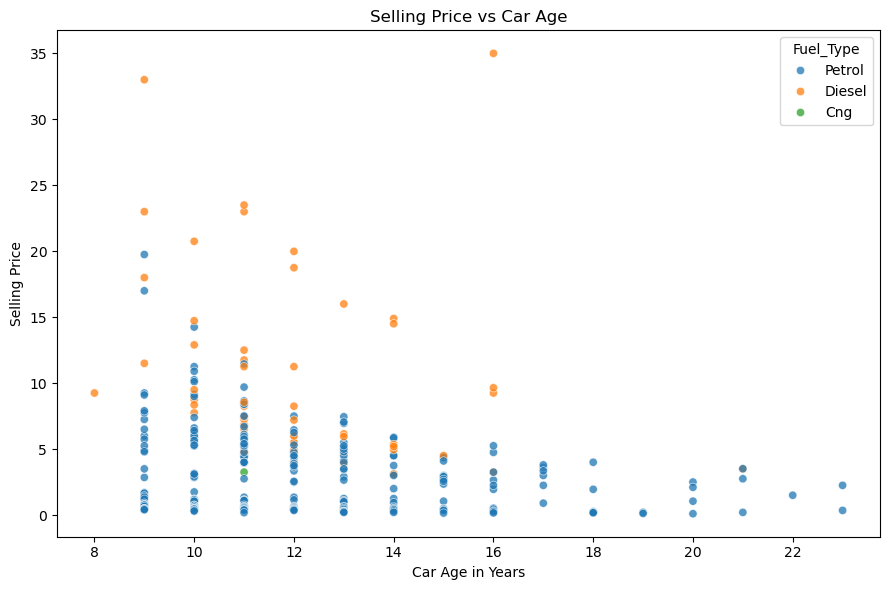

In [8]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=car_df,
    x="Car_Age",
    y="Selling_Price",
    hue="Fuel_Type",
    alpha=0.75
)
plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age in Years")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.show()

In [ ]:
numeric_car = car_df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_car.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap — Car Dataset")
plt.tight_layout()
plt.show()

## 3.4 Feature Preparation

`Selling_Price` is the target. Categorical columns are one-hot encoded.


In [9]:
target_car = "Selling_Price"

car_features = [
    "Present_Price",
    "Kms_Driven",
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner",
    "Car_Age",
    "Brand"
]

X_car = car_df[car_features]
y_car = car_df[target_car]

numeric_features_car = [
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age"
]

categorical_features_car = [
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Brand"
]

try:
    encoder_car = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder_car = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor_car = ColumnTransformer([
    ("num", "passthrough", numeric_features_car),
    ("cat", encoder_car, categorical_features_car)
])

X_train_car, X_test_car, y_train_car, y_test_car = train_test_split(
    X_car,
    y_car,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train_car))
print("Testing samples:", len(X_test_car))

Training samples: 239
Testing samples: 60


## 3.5 Train Two Regression Models


In [10]:
car_linear_model = Pipeline([
    ("preprocessor", preprocessor_car),
    ("model", LinearRegression())
])

car_rf_model = Pipeline([
    ("preprocessor", preprocessor_car),
    ("model", RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

car_linear_model.fit(X_train_car, y_train_car)
car_rf_model.fit(X_train_car, y_train_car)

car_linear_pred = car_linear_model.predict(X_test_car)
car_rf_pred = car_rf_model.predict(X_test_car)

print("Both regression models trained successfully.")

Both regression models trained successfully.


In [11]:
def regression_metrics(y_true, predictions):
    return {
        "MAE": mean_absolute_error(y_true, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_true, predictions)),
        "R2": r2_score(y_true, predictions)
    }

car_results = pd.DataFrame({
    "Linear Regression": regression_metrics(y_test_car, car_linear_pred),
    "Random Forest": regression_metrics(y_test_car, car_rf_pred)
}).T

display(car_results.sort_values("RMSE"))

,MAE,RMSE,R2
Linear Regression,1.474063,2.795791,0.696723
Random Forest,1.364090,3.275316,0.583767


## 3.6 Best Car Price Model


In [12]:
best_car_model_name = car_results["RMSE"].idxmin()

print(f"Best performing car price model: {best_car_model_name}")
print(
    "Selection is based primarily on the lowest test set RMSE, "
    "with MAE and R² used as supporting measures."
)

Best performing car price model: Linear Regression
Selection is based primarily on the lowest test set RMSE, with MAE and R² used as supporting measures.


## 3.7 Feature Importance — Random Forest


C:\Users\ntomb\AppData\Local\Temp\ipykernel_10172\1756943428.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, y="Feature", x="Importance", palette="viridis")


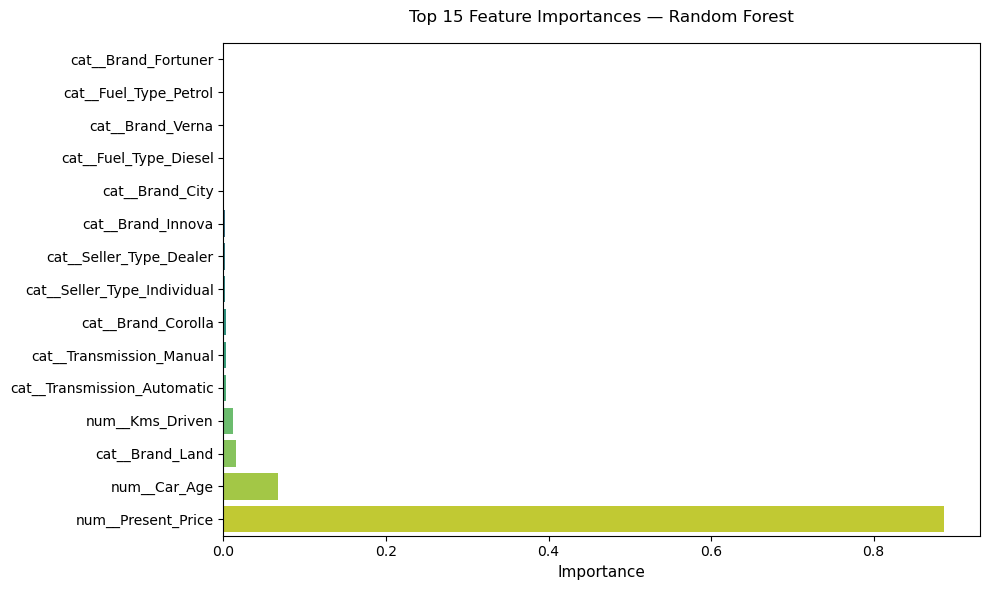

In [13]:
# Extract the fitted components
preprocessor = car_rf_model.named_steps["preprocessor"]
model = car_rf_model.named_steps["model"]

# Get feature importances with their names
features = preprocessor.get_feature_names_out()
importances = model.feature_importances_

#sorting the results
importance_df = pd.DataFrame({"Feature": features, "Importance": importances})
importance_df = importance_df.sort_values("Importance", ascending=True).tail(15)

# Visuals
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, y="Feature", x="Importance", palette="viridis")
plt.xlabel("Importance", fontsize=11)
plt.ylabel("")
plt.title("Top 15 Feature Importances — Random Forest", fontsize=12, pad=15)
plt.tight_layout()
plt.show()

### Task 3 Interpretation

The feature importance chart shows which variables were most useful to the Random Forest.
